In [6]:
"""Proposal-faithful RQ7 artifact generator for the revised complementary-value question.

This script reads frozen Phase 3 raw outputs and generates only the
proposal-facing RQ7 artifacts in a separate reporting layer.
"""

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import average_precision_score, roc_auc_score


sns.set_theme(style="whitegrid")


# Update this path in Kaggle before running.
PHASE3_INPUT_ROOT = Path("/kaggle/input/datasets/ashwinwalunj/ashwin-thesis-outputs-phase3/thesis_outputs")
OUTPUT_ROOT = Path("/kaggle/working/thesis_outputs")

RQ = "rq7"
RQ_OUTPUT_ROOT = OUTPUT_ROOT / "results_proposal" / RQ
FIGURES_ROOT = RQ_OUTPUT_ROOT / "figures"
TABLES_ROOT = RQ_OUTPUT_ROOT / "tables"
for folder in [FIGURES_ROOT, TABLES_ROOT]:
    folder.mkdir(parents=True, exist_ok=True)


def save_table(df, name):
    df.to_csv(TABLES_ROOT / f"{name}.csv", index=False)


def save_figure(fig, name):
    fig.savefig(FIGURES_ROOT / f"{name}.png", dpi=300, bbox_inches="tight")
    fig.savefig(FIGURES_ROOT / f"{name}.pdf", bbox_inches="tight")
    plt.show()


def precision_at_k(y_true, y_score, k):
    k = min(int(k), len(y_true))
    order = np.argsort(-y_score)[:k]
    return float(np.mean(y_true[order]))


def recall_at_k(y_true, y_score, k):
    k = min(int(k), len(y_true))
    order = np.argsort(-y_score)[:k]
    positives = max(int(np.sum(y_true)), 1)
    return float(np.sum(y_true[order]) / positives)


def ndcg_at_k(y_true, y_score, k):
    k = min(int(k), len(y_true))
    order = np.argsort(-y_score)[:k]
    gains = y_true[order]
    discounts = 1.0 / np.log2(np.arange(2, len(gains) + 2))
    dcg = float(np.sum(gains * discounts))

    ideal = np.sort(y_true)[::-1][:k]
    ideal_discounts = 1.0 / np.log2(np.arange(2, len(ideal) + 2))
    idcg = float(np.sum(ideal * ideal_discounts))
    if idcg <= 0:
        return 0.0
    return dcg / idcg


def simulate_daily_budget(score_df, score_col, budgets, target_col):
    rows = []
    for budget in budgets:
        for day_value, day_df in score_df.groupby("day_index"):
            ranked = day_df.sort_values(score_col, ascending=False).head(budget)
            fraud_found = int(ranked[target_col].sum())
            fraud_total = max(int(day_df[target_col].sum()), 1)
            rows.append(
                {
                    "Budget": int(budget),
                    "Day": int(day_value),
                    "ScoreColumn": score_col,
                    "FraudCaptured": fraud_found,
                    "DailyRecall": fraud_found / fraud_total,
                }
            )
    return pd.DataFrame(rows)


PHASE3_ARTIFACTS = PHASE3_INPUT_ROOT / "artifacts" / "phase03_ranking_explainability"
required_files = [
    PHASE3_ARTIFACTS / "ranking_predictions.parquet",
    PHASE3_ARTIFACTS / "ranking_efficiency_raw.csv",
    PHASE3_ARTIFACTS / "attention_ranker_summary.json",
]
for path in required_files:
    if not path.exists():
        raise FileNotFoundError(f"Missing Phase 3 raw file for RQ7: {path}")


ID_COL = "TransactionID"
TARGET_COL = "y_true"
BUDGETS = [50, 100, 250, 500]
OVERLAP_BUDGETS = [100, 250]
ALERT_QUANTILE_ROWS = [
    ("Top 1%", 0.01),
    ("Top 5%", 0.05),
    ("Top 10%", 0.10),
    ("Top 20%", 0.20),
]

MODEL_SCORE_MAP = {
    "XGBoost": "xgb_score",
    "TemporalGraphSAGE": "full_TemporalGraphSAGE_score",
    "WeightedBlend": "weighted_blend_score",
    "AttentionRanker": "attention_ranker_score",
}

ATTENTION_COLUMNS = {
    "LightGBM": "lgbm_score_attention",
    "XGBoost": "xgb_score_attention",
    "TemporalGraphSAGE": "full_TemporalGraphSAGE_score_attention",
    "GraphSAGE": "full_GraphSAGE_score_attention",
}


ranking_predictions_df = pd.read_parquet(PHASE3_ARTIFACTS / "ranking_predictions.parquet")
ranking_efficiency_df = pd.read_csv(PHASE3_ARTIFACTS / "ranking_efficiency_raw.csv")
rank_test_df = (
    ranking_predictions_df[ranking_predictions_df["split"] == "test"]
    .copy()
    .sort_values("TransactionDT")
    .reset_index(drop=True)
)

missing_score_cols = [col for col in MODEL_SCORE_MAP.values() if col not in rank_test_df.columns]
if missing_score_cols:
    raise ValueError(f"Missing required score columns for RQ7: {missing_score_cols}")

missing_attention_cols = [col for col in ATTENTION_COLUMNS.values() if col not in rank_test_df.columns]
if missing_attention_cols:
    raise ValueError(f"Missing required attention columns for RQ7: {missing_attention_cols}")

y_test = rank_test_df[TARGET_COL].astype(int).to_numpy()
xgb_score = rank_test_df["xgb_score"].to_numpy()

In [7]:
# Table 7.1 - Complementary Value Summary
summary_rows = []
for model_name, score_col in MODEL_SCORE_MAP.items():
    y_score = rank_test_df[score_col].to_numpy()
    summary_rows.append(
        {
            "Model": model_name,
            "AUC-PR": float(average_precision_score(y_test, y_score)),
            "Precision@100": precision_at_k(y_test, y_score, 100),
            "Recall@100": recall_at_k(y_test, y_score, 100),
            "NDCG@100": ndcg_at_k(y_test, y_score, 100),
            "Recall@Budget100": recall_at_k(y_test, y_score, 100),
            "Recall@Budget250": recall_at_k(y_test, y_score, 250),
            "Delta AUC-PR vs XGBoost": float(
                average_precision_score(y_test, y_score) - average_precision_score(y_test, xgb_score)
            ),
        }
    )

table_7_1 = pd.DataFrame(summary_rows).sort_values("AUC-PR", ascending=False).reset_index(drop=True)
save_table(table_7_1, "table_7_1_complementary_value_summary")

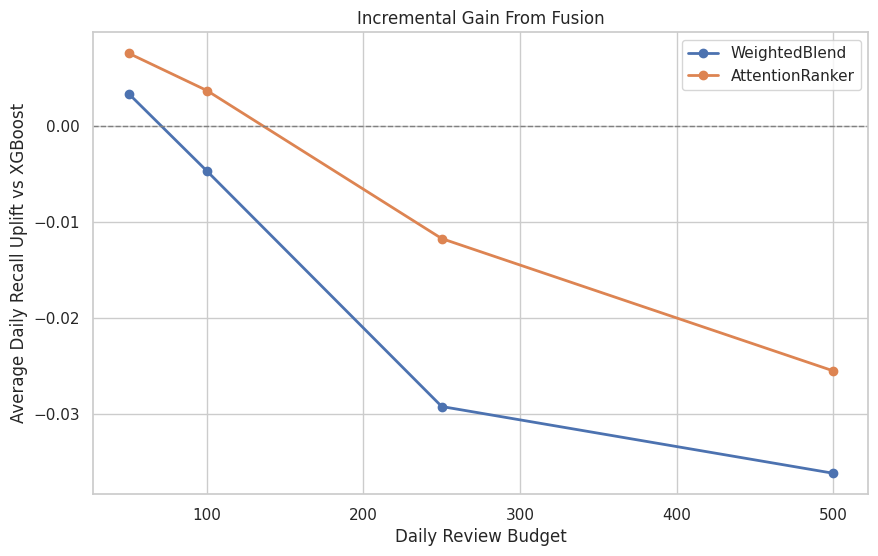

In [8]:
# Figure 7.1 - Incremental Gain From Fusion
daily_rows = []
for model_name, score_col in {
    "XGBoost": "xgb_score",
    "WeightedBlend": "weighted_blend_score",
    "AttentionRanker": "attention_ranker_score",
}.items():
    sim_df = simulate_daily_budget(rank_test_df, score_col, BUDGETS, TARGET_COL)
    sim_df["Model"] = model_name
    daily_rows.append(sim_df)

rq7_daily_df = pd.concat(daily_rows, axis=0, ignore_index=True)
avg_daily_recall_df = (
    rq7_daily_df.groupby(["Budget", "Model"], as_index=False)
    .agg(AvgDailyRecall=("DailyRecall", "mean"))
)
xgb_budget_lookup = (
    avg_daily_recall_df[avg_daily_recall_df["Model"] == "XGBoost"][["Budget", "AvgDailyRecall"]]
    .rename(columns={"AvgDailyRecall": "XGBoostRecall"})
)
uplift_df = avg_daily_recall_df.merge(xgb_budget_lookup, on="Budget", how="left")
uplift_df["RecallUpliftVsXGBoost"] = uplift_df["AvgDailyRecall"] - uplift_df["XGBoostRecall"]
uplift_df = uplift_df[uplift_df["Model"].isin(["WeightedBlend", "AttentionRanker"])].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 6))
for model_name in ["WeightedBlend", "AttentionRanker"]:
    plot_df = uplift_df[uplift_df["Model"] == model_name].sort_values("Budget")
    ax.plot(
        plot_df["Budget"],
        plot_df["RecallUpliftVsXGBoost"],
        marker="o",
        linewidth=2.0,
        label=model_name,
    )
ax.axhline(0.0, color="gray", linestyle="--", linewidth=1)
ax.set_title("Incremental Gain From Fusion")
ax.set_xlabel("Daily Review Budget")
ax.set_ylabel("Average Daily Recall Uplift vs XGBoost")
ax.legend()
save_figure(fig, "figure_7_1_incremental_gain_from_fusion")

In [9]:
# Table 7.2 - Unique Fraud Capture And Overlap
overlap_rows = []
total_fraud = int(rank_test_df[TARGET_COL].sum())
for budget in OVERLAP_BUDGETS:
    xgb_top = rank_test_df.sort_values("xgb_score", ascending=False).head(budget)
    attention_top = rank_test_df.sort_values("attention_ranker_score", ascending=False).head(budget)

    xgb_frauds = set(xgb_top.loc[xgb_top[TARGET_COL] == 1, ID_COL].astype(int).tolist())
    attention_frauds = set(attention_top.loc[attention_top[TARGET_COL] == 1, ID_COL].astype(int).tolist())

    overlap = xgb_frauds & attention_frauds
    unique_attention = attention_frauds - xgb_frauds
    unique_xgb = xgb_frauds - attention_frauds

    overlap_rows.append(
        {
            "Budget": int(budget),
            "FraudsCapturedByXGBoost": int(len(xgb_frauds)),
            "FraudsCapturedByAttentionRanker": int(len(attention_frauds)),
            "OverlapFrauds": int(len(overlap)),
            "UniqueToAttentionRanker": int(len(unique_attention)),
            "UniqueToXGBoost": int(len(unique_xgb)),
            "AttentionUniqueShareOfTestFraud": float(len(unique_attention) / max(total_fraud, 1)),
        }
    )

table_7_2 = pd.DataFrame(overlap_rows)
save_table(table_7_2, "table_7_2_unique_fraud_capture_and_overlap")

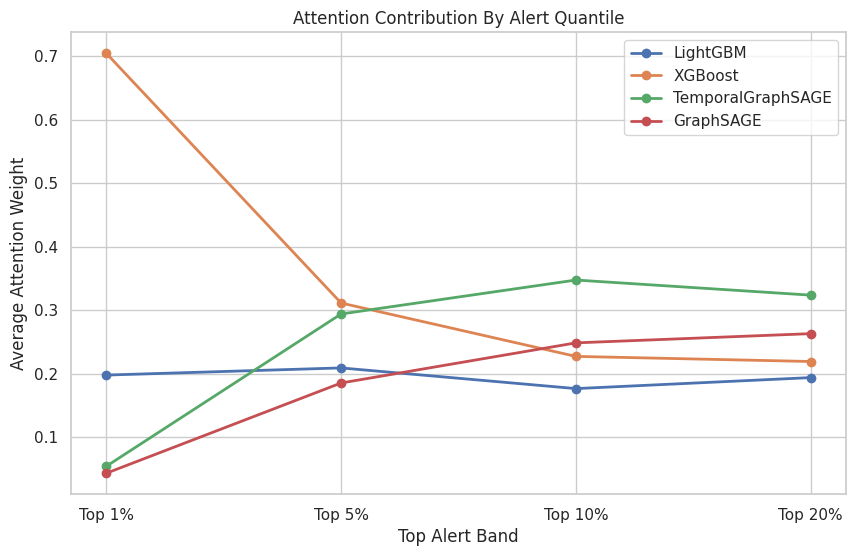

In [10]:
# Figure 7.2 - Attention Contribution By Alert Quantile
sorted_df = rank_test_df.sort_values("attention_ranker_score", ascending=False).reset_index(drop=True)
num_rows = len(sorted_df)
quantile_rows = []

for label, frac in ALERT_QUANTILE_ROWS:
    k = max(int(num_rows * frac), 1)
    top_df = sorted_df.head(k)
    row = {"AlertBand": label}
    for display_name, attn_col in ATTENTION_COLUMNS.items():
        row[display_name] = float(top_df[attn_col].mean())
    quantile_rows.append(row)

attention_quantile_df = pd.DataFrame(quantile_rows)

fig, ax = plt.subplots(figsize=(10, 6))
for display_name in ATTENTION_COLUMNS.keys():
    ax.plot(
        attention_quantile_df["AlertBand"],
        attention_quantile_df[display_name],
        marker="o",
        linewidth=2.0,
        label=display_name,
    )
ax.set_title("Attention Contribution By Alert Quantile")
ax.set_xlabel("Top Alert Band")
ax.set_ylabel("Average Attention Weight")
ax.legend()
save_figure(fig, "figure_7_2_attention_contribution_by_alert_quantile")